Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)


# Class 0
X0 = np.random.randn(50, 2) - 2
y0 = np.zeros(50)


# Class 1
X1 = np.random.randn(50, 2) + 2
y1 = np.ones(50)


# Combine
X = np.vstack((X0, X1))
y = np.hstack((y0, y1))

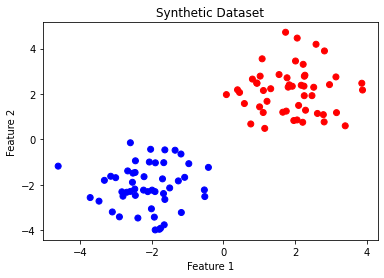

In [3]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic Dataset')
plt.show()

In [5]:
def train_test_split(X, y, test_size=0.2):
    n = len(X)
    test_count = int(n * test_size)
    indices = np.random.permutation(n)
    test_idx = indices[:test_count]
    train_idx = indices[test_count:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [6]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

class KNN:
    def __init__(self, k=3):
        self.k = k
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    def predict(self, X):
        predictions = []
        for x in X:
            distances = []
            for x_train in self.X_train:
                distances.append(euclidean_distance(x, x_train))
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]
            
            prediction = np.bincount(k_labels.astype(int)).argmax()
            predictions.append(prediction)
        
        return np.array(predictions)

In [7]:
knn = KNN(k=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [8]:
def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)


knn_accuracy = accuracy(y_test, y_pred_knn)
knn_accuracy

1.0

In [9]:
class SVM:
    def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None
    def fit(self, X, y):
        y_ = np.where(y <= 0, -1, 1)
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]

    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.sign(approx)

In [10]:
svm = SVM()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)


# Convert -1/+1 to 0/1
y_pred_svm = np.where(y_pred_svm == -1, 0, 1)

In [11]:
svm_accuracy = accuracy(y_test, y_pred_svm)
svm_accuracy

1.0

In [12]:
print("KNN Accuracy:", knn_accuracy)
print("SVM Accuracy:", svm_accuracy)

KNN Accuracy: 1.0
SVM Accuracy: 1.0


In [13]:
print("KNN parameter k:", knn.k)
print("SVM learning rate:", svm.lr)
print("SVM lambda:", svm.lambda_param)
print("SVM iterations:", svm.n_iters)
print("SVM weights:", svm.w)
print("SVM bias:", svm.b)

KNN parameter k: 5
SVM learning rate: 0.001
SVM lambda: 0.01
SVM iterations: 1000
SVM weights: [0.5653824  0.69581976]
SVM bias: -0.09600000000000007


In [15]:
def confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp], [fn, tp]])

In [16]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix - KNN:\n", cm_knn)
print("Confusion Matrix - SVM:\n", cm_svm)

Confusion Matrix - KNN:
 [[ 8  0]
 [ 0 12]]
Confusion Matrix - SVM:
 [[ 8  0]
 [ 0 12]]


In [17]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

print("KNN Accuracy:", accuracy(y_test, y_pred_knn))
print("SVM Accuracy:", accuracy(y_test, y_pred_svm))

KNN Accuracy: 1.0
SVM Accuracy: 1.0
